### CONEXION DDBB OLIST

In [1]:
%pip install PyMySQL
from sqlalchemy import create_engine, text
import ssl

## CONEXION BBDD MYSQL ##
DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

# Crear engine apuntando a la base 'olist'
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}} 
)

# tablas 'olist'
with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()
    tables = [row[0] for row in tables]   # convertir a lista simple de strings
    
    print("Tablas en la base 'olist':")
    for t in tables:
        print("-", t)



Note: you may need to restart the kernel to use updated packages.
Tablas en la base 'olist':
- dash_olist_categorias_resumen
- dash_olist_demorados
- dash_olist_sellers
- dash_olist_states
- dash_olist_ventas_meses
- dash_sentiment_analysis
- distribucion_pedidos
- olist_customers_dataset
- olist_geolocation_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset
- pedidos_por_tiempo
- product_category_name_translation


In [4]:
import pandas as pd
from IPython.display import display, Markdown

# Cargar los datos desde SQL, excluyendo pedidos cancelados
query = """
SELECT 
    pct.product_category_name_english AS product_category_name,
    i.price,
    o.order_id,
    o.order_purchase_timestamp
FROM olist_order_items_dataset i
LEFT JOIN olist_products_dataset p
    ON i.product_id = p.product_id
LEFT JOIN product_category_name_translation pct
    ON p.product_category_name = pct.product_category_name
LEFT JOIN olist_orders_dataset o
    ON i.order_id = o.order_id
WHERE o.order_status <> 'canceled'
"""
df = pd.read_sql_query(query, con=engine)

# Convertir fechas y extraer el año
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")
df["order_year"] = df["order_purchase_timestamp"].dt.year

# Calcular las ventas totales por año y categoría
ventas_anuales = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(total_sales=("price", "sum"))
      .reset_index()
)

# Calcular el número de pedidos por año y categoría
pedidos_anuales = (
    df.groupby(["product_category_name", "order_year"], dropna=False)
      .agg(order_count=("order_id", "nunique"))
      .reset_index()
)

# Pivotar los resultados para tener un formato por columnas de año
pivot_sales = (
    ventas_anuales.pivot(index="product_category_name", columns="order_year", values="total_sales")
    .fillna(0)
    .reset_index()
)

pivot_orders = (
    pedidos_anuales.pivot(index="product_category_name", columns="order_year", values="order_count")
    .fillna(0)
    .astype(int)
    .reset_index()
)

# Renombrar columnas para mayor claridad
if 2016 in pivot_sales.columns:
    pivot_sales.rename(columns={2016: "TotalSales_2016"}, inplace=True)
if 2017 in pivot_sales.columns:
    pivot_sales.rename(columns={2017: "TotalSales_2017"}, inplace=True)
if 2018 in pivot_sales.columns:
    pivot_sales.rename(columns={2018: "TotalSales_2018"}, inplace=True)

if 2017 in pivot_orders.columns:
    pivot_orders.rename(columns={2017: "OrderCount_2017"}, inplace=True)
if 2018 in pivot_orders.columns:
    pivot_orders.rename(columns={2018: "OrderCount_2018"}, inplace=True)

# Combinar las tablas de ventas y pedidos
merged_df = pd.merge(pivot_sales, pivot_orders, on="product_category_name", how="left")

# Ordenar por las ventas del último año
merged_df = merged_df.sort_values(by="TotalSales_2018", ascending=False)

# Mostrar resultados
display(Markdown("#### Ventas y número de pedidos por categoría (2016–2018)"))
display(
    merged_df[
        [
            "product_category_name",
            "TotalSales_2016",
            "TotalSales_2017",
            "TotalSales_2018",
            "OrderCount_2017",
            "OrderCount_2018"
        ]
    ].head(20)
)


#### Ventas y número de pedidos por categoría (2016–2018)

order_year,product_category_name,TotalSales_2016,TotalSales_2017,TotalSales_2018,OrderCount_2017,OrderCount_2018
44,health_beauty,4549.59,481142.73,770002.81,3382,5375
71,watches_gifts,3360.24,486519.02,708305.95,2114,3485
8,bed_bath_table,478.99,497970.94,537514.13,4496,4898
66,sports_leisure,2012.15,447546.59,530182.18,3621,4035
16,computers_accessories,1399.32,400490.61,502432.09,2606,4030
50,housewares,1287.07,227850.67,397688.06,2439,3399
40,furniture_decor,5880.78,336272.26,385312.01,3187,3186
6,auto,1443.25,238545.04,346632.44,1415,2448
7,baby,1530.16,152854.33,256086.70,1203,1656
21,cool_stuff,1111.00,388971.98,230752.41,2200,1409


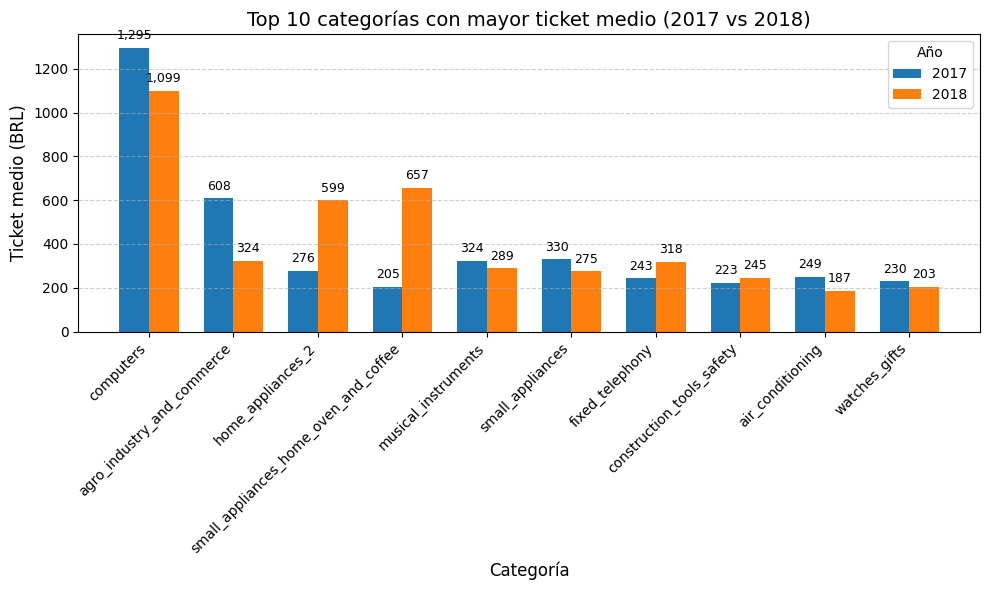

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Forzar conversión a numérico (float)
for col in ["TotalSales_2017", "TotalSales_2018", "OrderCount_2017", "OrderCount_2018"]:
    merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce").astype(float)

# Calcular el ticket medio (ventas / pedidos)
merged_df["AvgTicket_2017"] = (
    merged_df["TotalSales_2017"].astype(float) /
    merged_df["OrderCount_2017"].replace(0, np.nan).astype(float)
)
merged_df["AvgTicket_2018"] = (
    merged_df["TotalSales_2018"].astype(float) /
    merged_df["OrderCount_2018"].replace(0, np.nan).astype(float)
)

# Redondear después del cálculo (ya como float real)
merged_df["AvgTicket_2017"] = merged_df["AvgTicket_2017"].round(2)
merged_df["AvgTicket_2018"] = merged_df["AvgTicket_2018"].round(2)

# Calcular promedio y top 10
merged_df["AvgTicket_Mean"] = merged_df[["AvgTicket_2017", "AvgTicket_2018"]].mean(axis=1)
top10 = merged_df.sort_values("AvgTicket_Mean", ascending=False).head(10)

# Reestructurar datos
ticket_data = top10.melt(
    id_vars="product_category_name",
    value_vars=["AvgTicket_2017", "AvgTicket_2018"],
    var_name="Year",
    value_name="AvgTicket"
)
ticket_data["Year"] = ticket_data["Year"].str.extract(r"(\d{4})").astype(int)

# Gráfico
plt.figure(figsize=(10, 6))
bar_width = 0.35
years = sorted(ticket_data["Year"].unique())

for i, year in enumerate(years):
    subset = ticket_data[ticket_data["Year"] == year]
    bars = plt.bar(
        [x + (i * bar_width) for x in range(len(subset))],
        subset["AvgTicket"],
        width=bar_width,
        label=str(year)
    )
    # Etiquetas
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + (0.02 * max(ticket_data["AvgTicket"])),
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Formato final
plt.xticks(
    [x + bar_width / 2 for x in range(len(top10))],
    top10["product_category_name"],
    rotation=45,
    ha="right"
)
plt.title("Top 10 categorías con mayor ticket medio (2017 vs 2018)", fontsize=14)
plt.xlabel("Categoría", fontsize=12)
plt.ylabel("Ticket medio (BRL)", fontsize=12)
plt.legend(title="Año")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
